# physprior — what does a physics prior buy you?

A neural network can fit almost any curve. A physicist writes a law with two
constants in it. On **real measured data** — and on **simulations where the
answer is known exactly** — which should you use, and for what?

Three problems, each a subpackage under `physprior.problems`:

| Problem | Real data | Simulations |
|---|---|---|
| [`gravity`](01_gravity.ipynb) | Kepler's third law, JPL DE441 | two-body orbits, the three-body problem, the solar system |
| [`relativity`](02_relativity.ipynb) | GW150914 strain, Mercury's ephemeris | Schwarzschild orbits, inspiral waveforms, light bending |
| [`quantum`](03_quantum.ipynb) | NIST hydrogen levels, COBE/FIRAS | the Schrödinger equation, bound states and tunnelling |

Five arms everywhere: `oracle` (published law) · `physics` (law, fitted) ·
`pinn` (law + network) · `sr` (symbolic regression) · `nn` (black box).

**Why both real data and simulation.** The simulations are the control. When
the law is exactly what we put in, whatever a method fails to recover is the
*method's* error — its noise floor. Every real-data number is read against
that floor.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Physical constants recovered, across all problems

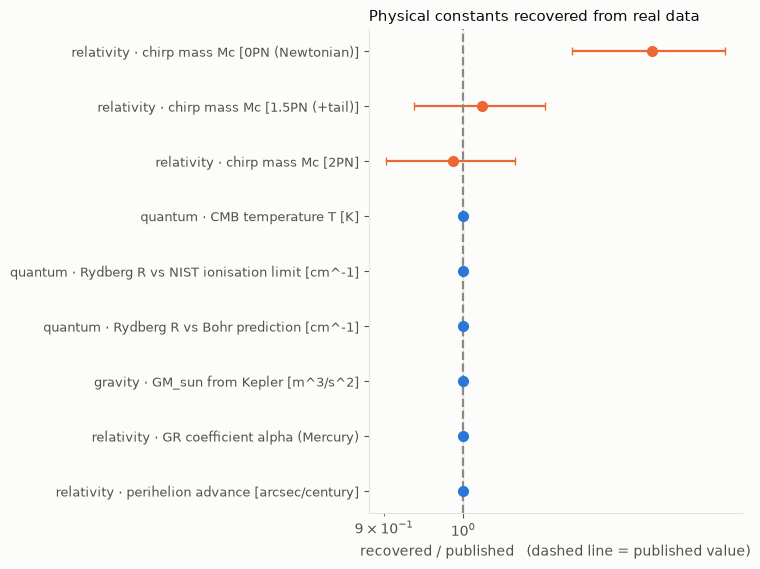

,track,quantity,published,recovered,sigma,deviation
0,relativity,chirp mass Mc [0PN (Newtonian)],3.117400e+01,4.007495e+01,4.057243e+00,+8.90 Msun (+2.19 sigma)
1,relativity,chirp mass Mc [1PN],3.117400e+01,NaN,NaN,fit pinned to bound (did not converge)
2,relativity,chirp mass Mc [1.5PN (+tail)],3.117400e+01,3.196558e+01,2.779950e+00,+0.79 Msun (+0.28 sigma)
3,relativity,chirp mass Mc [2PN],3.117400e+01,3.075471e+01,2.634620e+00,-0.42 Msun (-0.16 sigma)
4,quantum,CMB temperature T [K],2.725480e+00,2.725015e+00,7.577835e-06,-170 ppm (partly by construction - see caveat)
5,quantum,Rydberg R vs NIST ionisation limit [cm^-1],1.096788e+05,1.096788e+05,1.533770e-04,+51 ppb
6,quantum,Rydberg R vs Bohr prediction [cm^-1],1.096776e+05,1.096788e+05,1.533770e-04,+10.89 ppm = QED + relativistic
7,gravity,GM_sun from Kepler [m^3/s^2],1.327124e+20,1.327203e+20,3.377371e+15,+59.3 ppm
8,relativity,GR coefficient alpha (Mercury),1.000000e+00,1.000121e+00,1.654817e-05,+1.21e-04
9,relativity,perihelion advance [arcsec/century],4.298000e+01,4.298518e+01,NaN,+0.005


In [2]:
h = json.load(open(RESULTS / "headline.json"))
P.fig_parameter_recovery(h["parameter_recovery"]); plt.show()
pd.DataFrame(h["parameter_recovery"])

## Extrapolation, across the benchmark tracks

Each arm is fitted on the *low* part of its range and asked to predict the
*high* part.

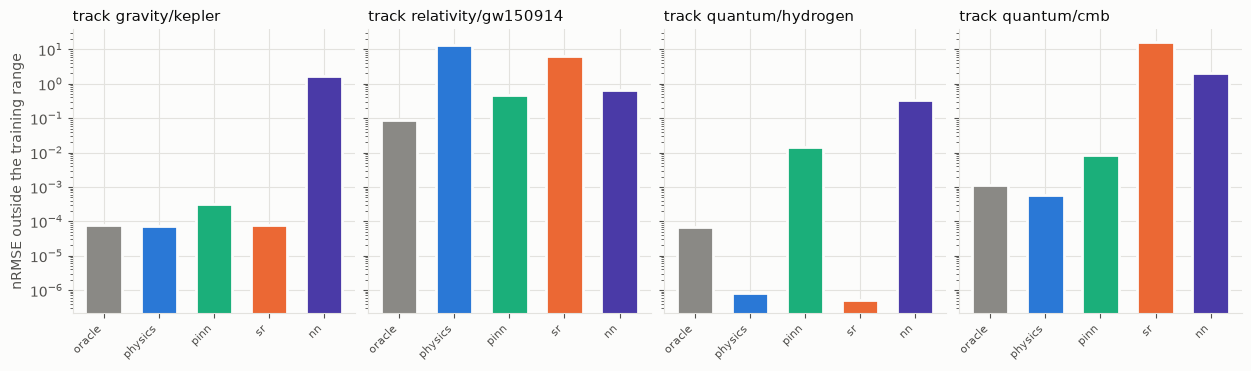

,track,arm,nrmse_in,nrmse_out,out/in
0,gravity/kepler,oracle,1.537401e-08,7.615129e-05,4953.250058
1,gravity/kepler,physics,1.144904e-08,7.558060e-05,6601.477587
2,gravity/kepler,pinn,5.724521e-09,3.278232e-04,57266.481653
3,gravity/kepler,sr,8.926247e-09,7.781677e-05,8717.748162
4,gravity/kepler,nn,2.123769e-05,1.660475e+00,78185.254618
5,relativity/gw150914,oracle,3.151804e-01,8.582349e-02,0.272300
6,relativity/gw150914,physics,2.679322e-01,1.344701e+01,50.188103
7,relativity/gw150914,pinn,1.933512e-01,4.567961e-01,2.362520
8,relativity/gw150914,sr,1.288187e-01,6.364213e+00,49.404411
9,relativity/gw150914,nn,1.310599e-03,6.820037e-01,520.375745


In [3]:
P.fig_cross_track_extrapolation(h["extrapolation_summary"]); plt.show()
pd.DataFrame(h["extrapolation_summary"])

### What each arm can do, and when the black box catches up

In [4]:
display(pd.DataFrame(h["capability_matrix"]))
display(pd.DataFrame(h["budget_crossover"]))
pd.DataFrame(h["oracle_sanity"])

,arm,returns a physical constant,returns a closed form,needs the law in advance,can be wrong in a new way
0,oracle,4/4 tracks,4/4 tracks,True,no - it is the reference
1,physics,4/4 tracks,4/4 tracks,True,yes - a truncated law gives a confident wrong ...
2,pinn,4/4 tracks,4/4 tracks (law + correction),True,yes - the network can absorb the physics if w_...
3,sr,0/4 tracks,4/4 tracks,False,"yes - fits the band, misses the law"
4,nn,0/4 tracks,0/4 tracks,False,no law to be wrong about; fails outside the ra...


,track,budgets swept,budgets where nn beats physics,nn wins at largest budget,nn nRMSE at max budget,physics nRMSE at max budget,physics advantage
0,gravity/kepler,3-6,none,False,0.030647,4.383008e-05,699.231235
1,relativity/gw150914,2-4,2,False,0.503232,3.959722e-01,1.270878
2,quantum/hydrogen,4-30,none,False,0.008736,7.270835e-07,12014.669197
3,quantum/cmb,5-30,none,False,0.003666,2.080255e-04,17.623167


,track,oracle nRMSE in,oracle nRMSE out,beat oracle in-range,beat oracle out-of-range,explanation
0,gravity/kepler,1.537401e-08,0.000076,"physics, pinn, sr",physics,the oracle carries the IAU nominal GM_sun; a f...
1,relativity/gw150914,3.151804e-01,0.085823,"nn, physics, pinn, sr",none,in-range: 4-5 training points against 2+ free ...
2,quantum/hydrogen,6.258366e-05,0.000068,"physics, pinn, sr","physics, sr","the oracle carries Bohr's R_H, which the data ..."
3,quantum/cmb,1.004351e-03,0.001149,"physics, pinn, sr",physics,the oracle carries T = 2.72548 K (Fixsen 2009)...


## The findings

1. **Inside the training range, with enough clean data, the black box is
   competitive.** Physics buys little there.
2. **Outside it the gap is orders of magnitude — but the mechanism is
   identifiability, not the mere presence of a law.** Track `quantum/cmb`
   shows out-of-band error falling ~56× as the fitted band reaches into the
   Rayleigh-Jeans regime, while the *in-band* error gets worse.
   `relativity/gw150914` is the counter-control: from four faint early cycles
   every fitted arm fails, physics included.
3. **Only the physics arms return something a physicist can argue with** — and
   three times in this project the argument was worth having: QED in hydrogen,
   the post-Newtonian expansion in GW150914, and a truncation error
   masquerading as a 56σ refutation of general relativity.
4. **The network eats the physics if you let it.** At `w_phys = 0` the
   recovered `GM_sun` is ~19% wrong while the held-out error barely moves.

See [`docs/TOOLING.md`](../docs/TOOLING.md) for which package does what and
exactly how a formula comes out of symbolic regression.